# Proyek Klasifikasi Gambar: Rice Image Detection
- **Nama:** Muhammad Fariduddin Athar
- **Email:** atharudin04@gmail.com
- **ID Dicoding:** itsfathar

## Import Semua Packages/Library yang Digunakan

In [16]:
!pip install tensorflowjs
!pip install tensorflow keras

In [17]:
import kagglehub
import tensorflow as tf
import keras
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflowjs as tfjs
import numpy as np
from tensorflow.keras.preprocessing import image

## Data Preparation

### Data Loading

In [18]:
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rice-image-dataset


In [19]:
dataset_path = os.path.join(path, "Rice_Image_Dataset")

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Subfolder (kelas):", dirs)
    print("Jumlah file langsung di dalamnya:", len(files))
    break

Folder: /kaggle/input/rice-image-dataset/Rice_Image_Dataset
Subfolder (kelas): ['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']
Jumlah file langsung di dalamnya: 1


In [20]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} gambar")

Karacadag: 15000 gambar
Basmati: 15000 gambar
Jasmine: 15000 gambar
Arborio: 15000 gambar
Ipsala: 15000 gambar


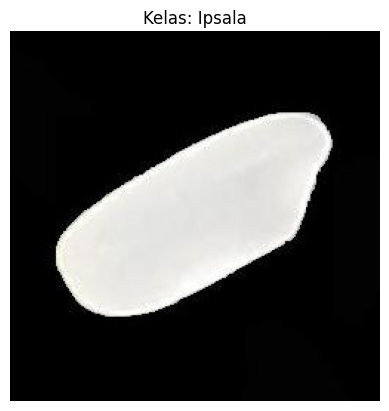

In [21]:
# Pilih salah satu kelas secara acak
kelas = random.choice(os.listdir(dataset_path))
folder_kelas = os.path.join(dataset_path, kelas)
gambar_acak = random.choice(os.listdir(folder_kelas))
path_gambar = os.path.join(folder_kelas, gambar_acak)

# Tampilkan gambar
img = mpimg.imread(path_gambar)
plt.imshow(img)
plt.title(f"Kelas: {kelas}")
plt.axis('off')
plt.show()

### Data Preprocessing

In [22]:
# Tentukan ukuran target gambar
target_size = (150, 150)  # Ukuran yang umum digunakan (misalnya 150x150)

# Setup ImageDataGenerator untuk normalisasi dan resize
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisasi pixel dari 0-255 menjadi 0-1
)

# Gunakan flow_from_directory untuk membaca dataset dan melakukan resize otomatis
train_generator = datagen.flow_from_directory(
    dataset_path,  # Path ke folder dataset
    target_size=target_size,  # Resize gambar ke ukuran target
    batch_size=32,  # Ukuran batch
    class_mode='categorical',  # Mode klasifikasi
    shuffle=True  # Acak data agar model belajar lebih baik
)

# Untuk melihat info data, kita bisa print class_mode dan class_indices:
print("Class mode:", train_generator.class_mode)
print("Class indices:", train_generator.class_indices)

Found 75000 images belonging to 5 classes.
Class mode: categorical
Class indices: {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


#### Split Dataset

In [23]:
# Path asal dataset (folder berisi folder kelas)
source_dir = "/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset"
base_output_dir = "/kaggle/working/dataset_split"

# Rasio split
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

# Loop setiap kelas
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue  # Lewati file seperti .txt

    # Ambil semua file gambar
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    split_data = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    # Salin file ke masing-masing folder split
    for split, img_list in split_data.items():
        split_class_dir = os.path.join(base_output_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img_name in img_list:
            src_path = os.path.join(class_path, img_name)
            dst_path = os.path.join(split_class_dir, img_name)
            shutil.copyfile(src_path, dst_path)

print("✅ Dataset berhasil dibagi menjadi train, val, dan test!")

✅ Dataset berhasil dibagi menjadi train, val, dan test!


In [24]:
# Contoh melihat 1 batch
x_batch, y_batch = next(train_generator)
print("Shape gambar:", x_batch.shape)
print("Shape label :", y_batch.shape)

Shape gambar: (32, 150, 150, 3)
Shape label : (32, 5)


## Modelling

In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path folder hasil split
train_dir = "/kaggle/working/dataset_split/train"
val_dir   = "/kaggle/working/dataset_split/val"
test_dir  = "/kaggle/working/dataset_split/test"

# Preprocessing dan augmentasi ringan
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Parameter
target_size = (150, 150)
batch_size = 32
class_mode = 'categorical'

# Data loader
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=target_size, batch_size=batch_size,
    class_mode=class_mode, shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=target_size, batch_size=batch_size,
    class_mode=class_mode, shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=target_size, batch_size=batch_size,
    class_mode=class_mode, shuffle=False
)

# Dapetin jumlah kelas otomatis
num_classes = train_generator.num_classes

# === MODEL CNN ===
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Train model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Found 62997 images belonging to 5 classes.
Found 26973 images belonging to 5 classes.
Found 26985 images belonging to 5 classes.
Epoch 1/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7843 - loss: 0.5290

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3016s 2s/step - accuracy: 0.7843 - loss: 0.5289 - val_accuracy: 0.9868 - val_loss: 0.0401
Epoch 2/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3017s 2s/step - accuracy: 0.9617 - loss: 0.1145 - val_accuracy: 0.9865 - val_loss: 0.0407
Epoch 3/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9736 - loss: 0.0803

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3017s 2s/step - accuracy: 0.9736 - loss: 0.0803 - val_accuracy: 0.9899 - val_loss: 0.0294
Epoch 4/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3029s 2s/step - accuracy: 0.9765 - loss: 0.0702 - val_accuracy: 0.9889 - val_loss: 0.0355
Epoch 5/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9791 - loss: 0.0666

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3025s 2s/step - accuracy: 0.9791 - loss: 0.0666 - val_accuracy: 0.9899 - val_loss: 0.0295
Epoch 6/20
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 3021s 2s/step - accuracy: 0.9842 - loss: 0.0530 - val_accuracy: 0.9788 - val_loss: 0.0766


## Evaluasi dan Visualisasi

844/844 ━━━━━━━━━━━━━━━━━━━━ 318s 377ms/step - accuracy: 0.9900 - loss: 0.0286

📊 Akurasi di Test Set: 0.9904
844/844 ━━━━━━━━━━━━━━━━━━━━ 318s 377ms/step - accuracy: 0.9900 - loss: 0.0286
🧪 Akurasi Test Set: 0.9904
843/843 ━━━━━━━━━━━━━━━━━━━━ 318s 377ms/step - accuracy: 0.9899 - loss: 0.0302
🎯 Akurasi Validation Set: 0.9899


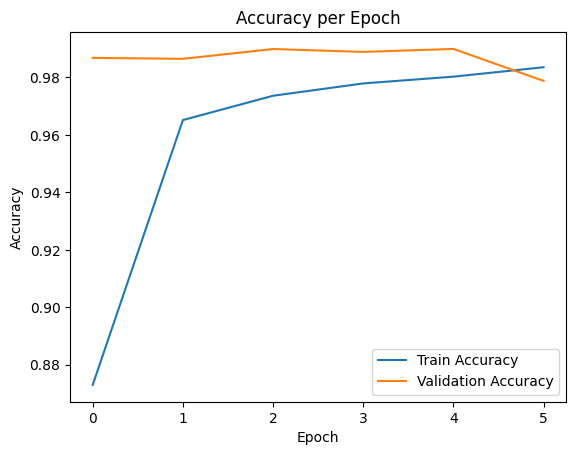

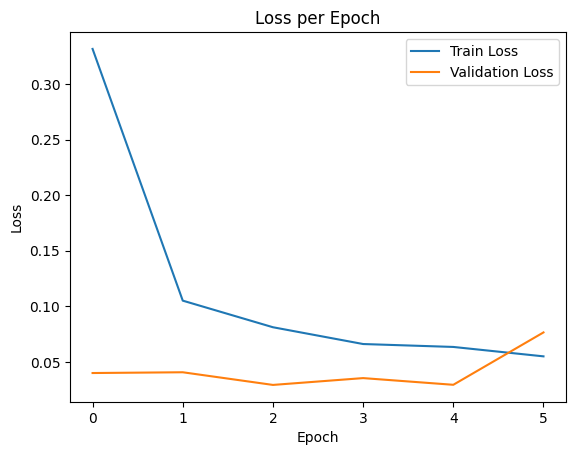

In [26]:

# Evaluasi awal di test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n📊 Akurasi di Test Set: {test_acc:.4f}")

test_loss, test_acc = model.evaluate(test_generator)
print(f"🧪 Akurasi Test Set: {test_acc:.4f}")

val_loss, val_acc = model.evaluate(val_generator)
print(f"🎯 Akurasi Validation Set: {val_acc:.4f}")

# Akurasi
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Konversi Model

###SavedModel

In [53]:
# Save ulang ke SavedModel format
tf.saved_model.save(model, 'mymodel/')
print("✅ Model berhasil disimpan dalam format SavedModel!")

✅ Model berhasil disimpan dalam format SavedModel!


###TF-Lite

In [32]:
model = keras.models.load_model('rice_classifier.h5')

# Buat converter dari Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Konversi
tflite_model = converter.convert()

# Simpan ke file
with open('rice_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Successfully converted .h5 to TFLite!")

Saved artifact at '/tmp/tmpjwd8rez7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133875774159760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774158800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774158608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774156880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774156688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774157648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774157456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774155728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774158992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133875774154576: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Successfully 

In [56]:
# Asumsi class_names udah ada dari folder split tadi
class_names = sorted(os.listdir('/kaggle/working/dataset_split/train'))

# Simpan ke label.txt
with open('/content/label.txt', 'w') as f:
    for class_name in class_names:
        f.write(class_name + '\n')

print("✅ label.txt berhasil dibuat!")

✅ label.txt berhasil dibuat!


###TFJS

In [33]:
import tensorflowjs as tfjs

# Konversi ke TFJS format
tfjs.converters.save_keras_model(model, "tfjs_model")
print("✅ Converted and saved as TensorFlow.js format!")

failed to lookup keras version from the file,
    this is likely a weight only file
✅ Converted and saved as TensorFlow.js format!


## Inference (Optional)

In [46]:
# Load ulang model
model_loaded = tf.keras.models.load_model("/content/rice_classifier.h5")
model.compile()

# Load satu gambar dari test set
img_path = "/content/gambar_test.jpg"
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # bikin jadi batch
img_array = img_array / 255.0  # ingat normalisasi

# Prediksi
prediction = model_loaded.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

# Kelas-kelas (samakan urutannya dengan generator)
class_labels = list(train_generator.class_indices.keys())

print("Prediksi:", class_labels[predicted_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
Prediksi: Ipsala


## Requirements.txt

In [47]:
!pip freeze > requirements.txt